# SC-OTS Tabular Benchmark Suite: 10 Datasets with Ground-Truth Interactions

This notebook demonstrates the **SC-OTS Tabular Benchmark Suite**, a collection of 10 curated tabular datasets designed for evaluating feature interaction detection in interpretable ML models.

**What this artifact does:**
- Assembles 10 tabular datasets (4 synthetic with ground-truth interactions, 4 real-world well-studied, 2 medium-complexity)
- Preprocesses each dataset: handles missing values, encodes categoricals, creates standardized feature arrays
- Creates 5-fold cross-validation splits with stratification for classification tasks
- Outputs standardized JSON with rich metadata (task type, feature names, known interactions, domain hints)

**Dataset categories:**
- **A_synthetic**: Known ground-truth interactions for validation (friedman1, friedman3, synth_3way, synth_4way)
- **B_realworld**: Well-studied datasets from FIGS/EBM/RO-FIGS literature (diabetes, breast_w, adult, wine_quality, california_housing)
- **C_medium_complexity**: 40-200 features with plausible higher-order interactions (spambase)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

## Data Loading

Load the benchmark data from GitHub (with local fallback for development).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/dataset_iter1_sc_ots_tabular/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded benchmark: {data['metadata']['benchmark_name']}")
print(f"Datasets: {data['metadata']['n_datasets']}")
print(f"Total examples (full): {data['metadata']['total_examples']}")
print(f"Examples in demo: {sum(len(d['examples']) for d in data['datasets'])}")

Loaded benchmark: SC-OTS Tabular Benchmark v1
Datasets: 10
Total examples (full): 63205
Examples in demo: 30


## Configuration

Tunable parameters for exploring the benchmark suite.

In [5]:
# --- Config ---
# Number of CV folds used in the benchmark
N_SPLITS = 5
# Random state for reproducibility
RANDOM_STATE = 42
# Maximum number of datasets to process in this demo
MAX_DATASETS = 10
# Maximum examples to display per dataset in detailed view
MAX_DISPLAY_EXAMPLES = 3

## Dataset Configurations

The original benchmark defines 10 datasets across three categories. Each has metadata about task type, source, and known feature interactions (for synthetic datasets) or domain hints (for real-world datasets).

In [6]:
# ── Dataset definitions (from original assembly script) ─────────────
DATASET_CONFIGS = [
    # Category A — Synthetic (regression, known ground-truth interactions)
    {
        "name": "friedman1",
        "task_type": "regression",
        "category": "A_synthetic",
        "source": "sklearn.datasets.make_friedman1",
        "known_interactions": {
            "2-way": [[0, 1]],
            "additive": [2, 3, 4],
            "noise_features": [5, 6, 7, 8, 9],
            "formula": "y = 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4",
        },
    },
    {
        "name": "friedman3",
        "task_type": "regression",
        "category": "A_synthetic",
        "source": "sklearn.datasets.make_friedman3",
        "known_interactions": {
            "3-way": [[0, 1, 2], [0, 1, 3]],
            "formula": "y = arctan((x1*x2 - 1/(x1*x3)) / x0)",
        },
    },
    {
        "name": "synth_3way",
        "task_type": "regression",
        "category": "A_synthetic",
        "source": "custom_generator",
        "known_interactions": {
            "3-way": [[0, 1, 2]],
            "2-way": [[3, 4]],
            "additive": [0],
            "noise_features": list(range(5, 15)),
            "formula": "y = 5*x0*x1*x2 + 3*sin(pi*x3*x4) + 2*x0 + noise",
        },
    },
    {
        "name": "synth_4way",
        "task_type": "regression",
        "category": "A_synthetic",
        "source": "custom_generator",
        "known_interactions": {
            "4-way": [[0, 1, 2, 3]],
            "2-way": [[4, 5]],
            "additive": [0, 4],
            "noise_features": list(range(6, 20)),
            "formula": "y = 4*x0*x1*x2*x3 + 3*x4*x5 + 2*x0 + 1.5*x4 + noise",
        },
    },
    # Category B — Real-world
    {
        "name": "diabetes",
        "task_type": "classification",
        "category": "B_realworld",
        "source": "OpenML ID 37 (Pima Indians)",
        "domain_hint": "BMI x skin_thickness, glucose x insulin",
    },
    {
        "name": "breast_w",
        "task_type": "classification",
        "category": "B_realworld",
        "source": "OpenML ID 15 (Wisconsin Breast Cancer)",
        "domain_hint": "cell_size x cell_shape, bare_nuclei x bland_chromatin",
    },
    {
        "name": "adult",
        "task_type": "classification",
        "category": "B_realworld",
        "source": "OpenML ID 1590 (Adult Census Income)",
        "domain_hint": "education x occupation, age x hours_per_week",
        "subsample": 10000,
    },
    {
        "name": "wine_quality",
        "task_type": "regression",
        "category": "B_realworld",
        "source": "OpenML ID 287 (Wine Quality)",
        "domain_hint": "acidity x pH, alcohol x residual_sugar",
    },
    {
        "name": "california_housing",
        "task_type": "regression",
        "category": "B_realworld",
        "source": "sklearn.datasets.fetch_california_housing",
        "domain_hint": "income x location(lat,lon), rooms x occupancy",
    },
    # Category C — Medium-complexity
    {
        "name": "spambase",
        "task_type": "classification",
        "category": "C_medium_complexity",
        "source": "OpenML ID 44 (Spambase)",
        "domain_hint": "word_freq x char_freq x capital_run_length",
    },
]

# Print summary
print(f"Defined {len(DATASET_CONFIGS)} dataset configurations:")
for cfg in DATASET_CONFIGS[:MAX_DATASETS]:
    interactions = ""
    if "known_interactions" in cfg:
        ki = cfg["known_interactions"]
        parts = [k for k in ki if k != "formula" and k != "noise_features" and k != "additive"]
        interactions = f" | interactions: {parts}"
    elif "domain_hint" in cfg:
        interactions = f" | hint: {cfg['domain_hint']}"
    print(f"  {cfg['name']:20s} [{cfg['category']}] {cfg['task_type']:15s}{interactions}")

Defined 10 dataset configurations:
  friedman1            [A_synthetic] regression      | interactions: ['2-way']
  friedman3            [A_synthetic] regression      | interactions: ['3-way']
  synth_3way           [A_synthetic] regression      | interactions: ['3-way', '2-way']
  synth_4way           [A_synthetic] regression      | interactions: ['4-way', '2-way']
  diabetes             [B_realworld] classification  | hint: BMI x skin_thickness, glucose x insulin
  breast_w             [B_realworld] classification  | hint: cell_size x cell_shape, bare_nuclei x bland_chromatin
  adult                [B_realworld] classification  | hint: education x occupation, age x hours_per_week
  wine_quality         [B_realworld] regression      | hint: acidity x pH, alcohol x residual_sugar
  california_housing   [B_realworld] regression      | hint: income x location(lat,lon), rooms x occupancy
  spambase             [C_medium_complexity] classification  | hint: word_freq x char_freq x capital_r

## Preprocessing Functions

These functions from the original assembly script handle dataset preprocessing, fold assignment, and output schema construction.

In [7]:
# ── Target label mappings ────────────────────────────────────────────
TARGET_MAP = {
    "diabetes": {"tested_positive": 1, "tested_negative": 0},
    "breast_w": {"malignant": 1, "benign": 0},
    "heart_c": {"P": 1, "N": 0},
    "adult": {">50K": 1, "<=50K": 0, ">50K.": 1, "<=50K.": 0},
    "spambase": {"1": 1, "0": 0, 1: 1, 0: 0},
    "ozone_level_8hr": {"1": 1, "2": 0, 1: 1, 2: 0},
    "qsar_biodeg": {"1": 1, "2": 0, 1: 1, 2: 0},
}


def preprocess_dataset(
    df: pd.DataFrame,
    dataset_name: str,
    task_type: str,
    subsample: int | None = None,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Preprocess a dataset: encode categoricals, handle missing values, encode target.

    Returns: (X_numeric, y, feature_names)
    """
    # Separate target
    target_col = "target"
    y_raw = df[target_col].copy()
    X_df = df.drop(columns=[target_col])

    # Drop molecule_name if present (categorical identifier, not a feature)
    if "molecule_name" in X_df.columns:
        X_df = X_df.drop(columns=["molecule_name"])

    # Subsample if needed
    if subsample is not None and len(X_df) > subsample:
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(len(X_df), size=subsample, replace=False)
        idx.sort()
        X_df = X_df.iloc[idx].reset_index(drop=True)
        y_raw = y_raw.iloc[idx].reset_index(drop=True)

    # Handle missing values
    numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

    cols_to_drop = []
    for col in numeric_cols:
        pct_missing = X_df[col].isna().mean()
        if pct_missing > 0.20:
            cols_to_drop.append(col)
        elif pct_missing > 0:
            X_df[col] = X_df[col].fillna(X_df[col].median())

    for col in cat_cols:
        pct_missing = X_df[col].isna().mean()
        if pct_missing > 0.20:
            cols_to_drop.append(col)
        elif pct_missing > 0:
            mode_val = X_df[col].mode()
            if len(mode_val) > 0:
                X_df[col] = X_df[col].fillna(mode_val.iloc[0])

    if cols_to_drop:
        print(f"  Dropping columns with >20% missing: {cols_to_drop}")
        X_df = X_df.drop(columns=cols_to_drop)
        numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
        cat_cols = [c for c in cat_cols if c not in cols_to_drop]

    # Drop remaining rows with NaN
    mask = X_df.isna().any(axis=1) | y_raw.isna()
    if mask.sum() > 0:
        print(f"  Dropping {mask.sum()} rows with remaining NaN")
        X_df = X_df[~mask].reset_index(drop=True)
        y_raw = y_raw[~mask].reset_index(drop=True)

    # One-hot encode categoricals
    if cat_cols:
        X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True, dtype=float)
        print(f"  One-hot encoded {len(cat_cols)} categorical columns -> {len(X_df.columns)} total features")

    # Encode target
    if task_type == "classification":
        mapping = TARGET_MAP.get(dataset_name)
        if mapping:
            y = y_raw.map(mapping)
            unmapped = y.isna().sum()
            if unmapped > 0:
                y = y.fillna(0)
            y = y.astype(int)
        else:
            try:
                y = y_raw.astype(float).astype(int)
            except (ValueError, TypeError):
                unique_labels = sorted(y_raw.unique())
                label_map = {v: i for i, v in enumerate(unique_labels)}
                y = y_raw.map(label_map).astype(int)
        y = y.values
    else:
        y = y_raw.astype(float).values

    feature_names = X_df.columns.tolist()
    X = X_df.values.astype(float)

    assert not np.isnan(X).any(), f"NaN found in X for {dataset_name}"
    assert not np.isnan(y).any(), f"NaN found in y for {dataset_name}"

    return X, y, feature_names


def create_fold_assignments(
    X: np.ndarray,
    y: np.ndarray,
    task_type: str,
    n_splits: int = N_SPLITS,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """Create fold assignments for k-fold CV."""
    if task_type == "classification":
        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_arg = y
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_arg = None

    fold_assignments = np.zeros(len(X), dtype=int)
    for fold_idx, (_, test_idx) in enumerate(kf.split(X, split_arg)):
        fold_assignments[test_idx] = fold_idx

    return fold_assignments


def build_dataset_entry(
    config: dict,
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    folds: np.ndarray,
) -> dict:
    """Build a single dataset entry in the output schema."""
    task_type = config["task_type"]
    n_samples, n_features = X.shape

    if task_type == "classification":
        n_classes = int(len(np.unique(y)))
    else:
        n_classes = 0

    examples = []
    for i in range(n_samples):
        input_vals = [round(float(v), 6) for v in X[i]]
        input_str = json.dumps(input_vals)

        if task_type == "classification":
            output_str = str(int(y[i]))
        else:
            output_str = str(round(float(y[i]), 6))

        example = {
            "input": input_str,
            "output": output_str,
            "metadata_fold": int(folds[i]),
            "metadata_feature_names": feature_names,
            "metadata_task_type": task_type,
            "metadata_category": config["category"],
            "metadata_row_index": i,
        }

        if task_type == "classification":
            example["metadata_n_classes"] = n_classes
        if "known_interactions" in config:
            example["metadata_known_interactions"] = json.dumps(config["known_interactions"])
        if "domain_hint" in config:
            example["metadata_domain_hint"] = config["domain_hint"]

        example["metadata_source"] = config["source"]
        example["metadata_n_features"] = n_features
        example["metadata_n_samples"] = n_samples

        examples.append(example)

    return {"dataset": config["name"], "examples": examples}

print("Preprocessing functions defined.")

Preprocessing functions defined.


## Explore Benchmark Data

Parse the loaded benchmark data and examine its structure: dataset names, example counts, feature dimensions, task types, and metadata.

In [8]:
# ── Explore loaded benchmark data ──
print("=" * 60)
print("Benchmark Metadata")
print("=" * 60)
print(f"Name: {data['metadata']['benchmark_name']}")
print(f"Description: {data['metadata']['description']}")
print(f"Categories:")
for cat, desc in data['metadata']['categories'].items():
    print(f"  {cat}: {desc}")

print(f"\n{'='*60}")
print("Dataset Summary")
print("=" * 60)

rows = []
for ds in data["datasets"][:MAX_DATASETS]:
    ex0 = ds["examples"][0]
    n_features = ex0["metadata_n_features"]
    task = ex0["metadata_task_type"]
    category = ex0["metadata_category"]
    n_samples_full = ex0["metadata_n_samples"]
    n_examples_demo = len(ds["examples"])

    # Parse first example to show structure
    input_vals = json.loads(ex0["input"])

    interactions = ""
    if "metadata_known_interactions" in ex0:
        ki = json.loads(ex0["metadata_known_interactions"])
        interaction_types = [k for k in ki if k not in ("formula", "noise_features", "additive")]
        interactions = ", ".join(interaction_types)
    elif "metadata_domain_hint" in ex0:
        interactions = ex0["metadata_domain_hint"][:30]

    rows.append({
        "Dataset": ds["dataset"],
        "Category": category.split("_")[0],
        "Task": task,
        "Features": n_features,
        "Samples (full)": n_samples_full,
        "Demo examples": n_examples_demo,
        "Interactions/Hints": interactions,
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

Benchmark Metadata
Name: SC-OTS Tabular Benchmark v1
Description: 10 tabular datasets (4 synthetic + 4 real-world + 2 medium-complexity) with standardized schema, 5-fold CV splits, and interaction metadata for SC-OTS evaluation
Categories:
  A_synthetic: Known ground-truth interactions for validation
  B_realworld: Well-studied datasets from FIGS/EBM/RO-FIGS literature
  C_medium_complexity: 40-200 features with plausible higher-order interactions

Dataset Summary
           Dataset Category           Task  Features  Samples (full)  Demo examples             Interactions/Hints
         friedman1        A     regression        10            5000              3                          2-way
         friedman3        A     regression         4            5000              3                          3-way
        synth_3way        A     regression        15            5000              3                   3-way, 2-way
        synth_4way        A     regression        20            5000   

## Validation Checks

Run the same validation logic from the original assembly script to verify data integrity: consistent input lengths, no NaN values, correct fold assignments, and valid target values.

In [9]:
# ── Validation checks (from original assembly script) ──
print("=" * 60)
print("Validation Checks")
print("=" * 60)

errors = []
for ds in data["datasets"][:MAX_DATASETS]:
    ds_name = ds["dataset"]
    examples = ds["examples"]

    # Check examples exist
    if len(examples) == 0:
        errors.append(f"{ds_name}: No examples")
        continue

    # Check all inputs have same length
    first_len = len(json.loads(examples[0]["input"]))
    for i, ex in enumerate(examples):
        inp = json.loads(ex["input"])
        if len(inp) != first_len:
            errors.append(f"{ds_name}: Example {i} input length {len(inp)} != {first_len}")
            break
        # Check no NaN
        if any(v != v for v in inp if isinstance(v, float)):
            errors.append(f"{ds_name}: NaN in example {i} input")
            break

    # Check folds (demo subset may not have all 5 folds)
    fold_vals = set(ex["metadata_fold"] for ex in examples)

    # Check feature_names length matches input
    n_feat = examples[0]["metadata_n_features"]
    if first_len != n_feat:
        errors.append(f"{ds_name}: Feature count mismatch: input len={first_len}, n_features={n_feat}")

    feat_names_len = len(examples[0]["metadata_feature_names"])
    if feat_names_len != first_len:
        errors.append(f"{ds_name}: feature_names length {feat_names_len} != input length {first_len}")

    # Check target values
    task = examples[0]["metadata_task_type"]
    if task == "classification":
        targets = set(ex["output"] for ex in examples)
        if not targets.issubset({"0", "1"}):
            errors.append(f"{ds_name}: Classification targets not binary: {targets}")
    else:
        for ex in examples[:MAX_DISPLAY_EXAMPLES]:
            try:
                v = float(ex["output"])
                if not np.isfinite(v):
                    errors.append(f"{ds_name}: Non-finite regression target: {v}")
                    break
            except ValueError:
                errors.append(f"{ds_name}: Non-numeric regression target: {ex['output']}")
                break

    print(f"  ✓ {ds_name}: {len(examples)} examples, {first_len} features, folds={sorted(fold_vals)}")

if errors:
    print(f"\n✗ VALIDATION FAILED with {len(errors)} errors:")
    for e in errors:
        print(f"  - {e}")
else:
    print(f"\n✓ All {len(data['datasets'][:MAX_DATASETS])} datasets passed validation!")

Validation Checks
  ✓ friedman1: 3 examples, 10 features, folds=[1, 3]
  ✓ friedman3: 3 examples, 4 features, folds=[1, 3]
  ✓ synth_3way: 3 examples, 15 features, folds=[1, 3]
  ✓ synth_4way: 3 examples, 20 features, folds=[1, 3]
  ✓ diabetes: 3 examples, 8 features, folds=[2, 3]
  ✓ breast_w: 3 examples, 9 features, folds=[0, 3]
  ✓ adult: 3 examples, 96 features, folds=[2, 4]
  ✓ wine_quality: 3 examples, 11 features, folds=[2, 3]
  ✓ california_housing: 3 examples, 8 features, folds=[0, 2, 3]
  ✓ spambase: 3 examples, 57 features, folds=[2, 4]

✓ All 10 datasets passed validation!


## Example Data Inspection

Examine individual examples from each dataset category: parse the JSON feature arrays, show target values, and display interaction metadata for synthetic datasets.

In [10]:
# ── Inspect examples from each category ──
categories_seen = set()
for ds in data["datasets"][:MAX_DATASETS]:
    ex0 = ds["examples"][0]
    cat = ex0["metadata_category"]
    if cat in categories_seen:
        continue
    categories_seen.add(cat)

    print(f"\n{'─'*60}")
    print(f"Category: {cat} | Dataset: {ds['dataset']}")
    print(f"{'─'*60}")

    # Show first example structure
    input_vals = json.loads(ex0["input"])
    feature_names = ex0["metadata_feature_names"]
    print(f"Task type: {ex0['metadata_task_type']}")
    print(f"Features ({len(feature_names)}): {feature_names[:8]}{'...' if len(feature_names) > 8 else ''}")
    print(f"Input (first 5 values): {input_vals[:5]}")
    print(f"Output: {ex0['output']}")
    print(f"Fold: {ex0['metadata_fold']}")
    print(f"Source: {ex0['metadata_source']}")

    if "metadata_known_interactions" in ex0:
        ki = json.loads(ex0["metadata_known_interactions"])
        print(f"Known interactions:")
        for k, v in ki.items():
            print(f"  {k}: {v}")
    elif "metadata_domain_hint" in ex0:
        print(f"Domain hint: {ex0['metadata_domain_hint']}")


────────────────────────────────────────────────────────────
Category: A_synthetic | Dataset: friedman1
────────────────────────────────────────────────────────────
Task type: regression
Features (10): ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7']...
Input (first 5 values): [0.37454, 0.950714, 0.731994, 0.598658, 0.156019]
Output: 16.836355
Fold: 1
Source: sklearn.datasets.make_friedman1
Known interactions:
  2-way: [[0, 1]]
  additive: [2, 3, 4]
  noise_features: [5, 6, 7, 8, 9]
  formula: y = 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4

────────────────────────────────────────────────────────────
Category: B_realworld | Dataset: diabetes
────────────────────────────────────────────────────────────
Task type: classification
Features (8): ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
Input (first 5 values): [6.0, 148.0, 72.0, 35.0, 0.0]
Output: 1
Fold: 2
Source: OpenML ID 37 (Pima Indians)
Domain hint: BMI x skin_thickness, glucose x insulin

─────────────────

## Visualization

Visualize the benchmark suite structure: dataset sizes (full benchmark), feature dimensionality, task type distribution, and category composition.

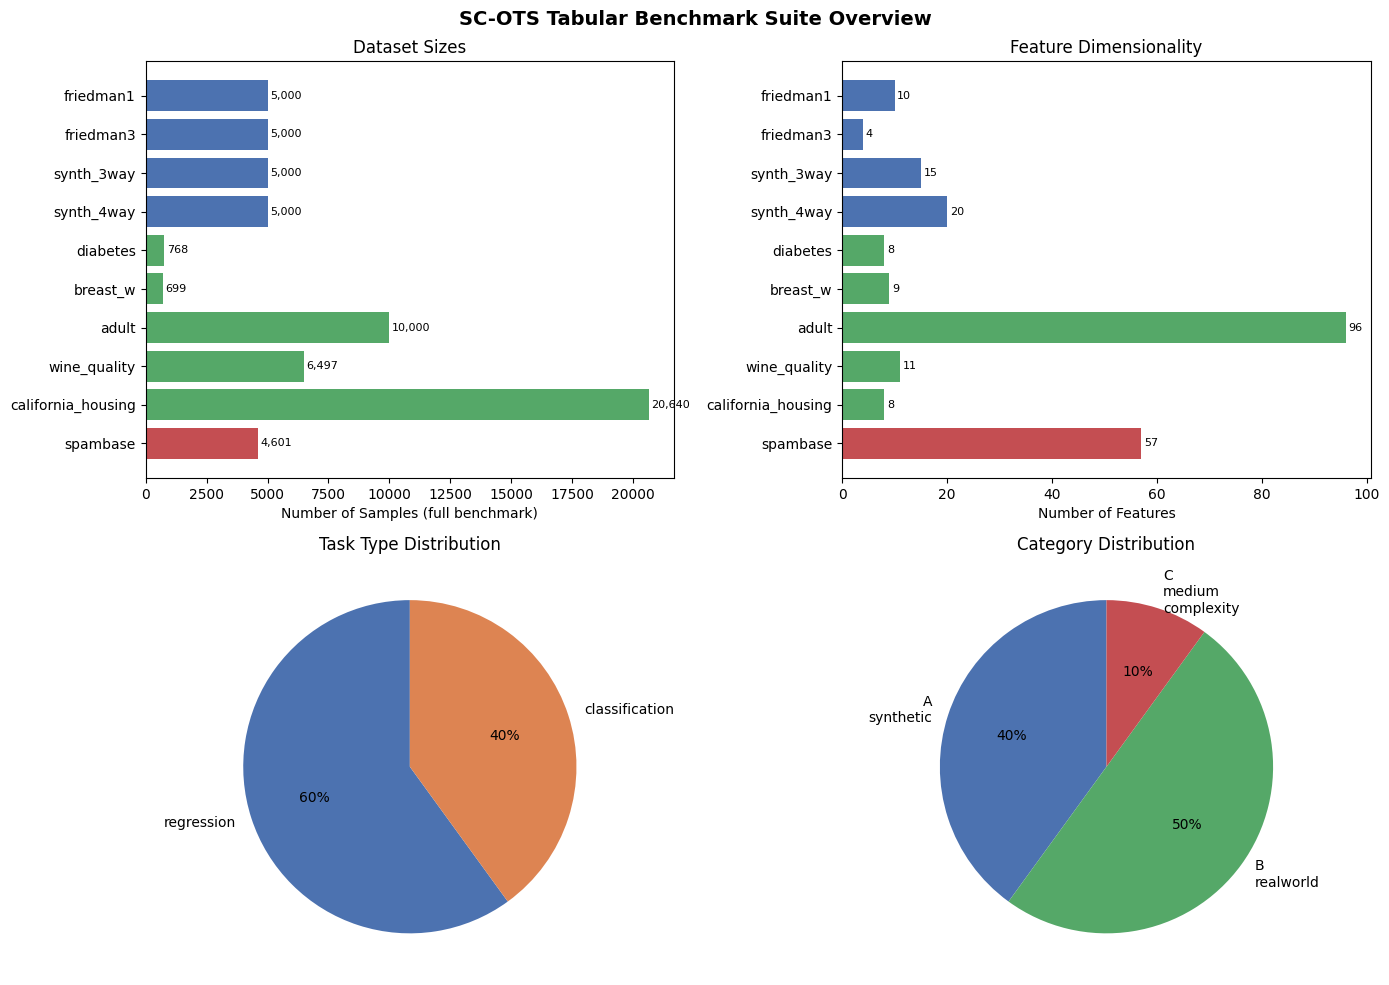


Benchmark Summary:
  Total datasets: 10
  Total examples (full): 63,205
  Feature range: 4-96
  Task types: {'regression': 6, 'classification': 4}
  Categories: {'A_synthetic': 4, 'B_realworld': 5, 'C_medium_complexity': 1}


In [11]:
# ── Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SC-OTS Tabular Benchmark Suite Overview", fontsize=14, fontweight="bold")

# Collect stats from loaded data
ds_names = []
n_samples_full = []
n_features_list = []
task_types = []
categories = []

for ds in data["datasets"][:MAX_DATASETS]:
    ex0 = ds["examples"][0]
    ds_names.append(ds["dataset"])
    n_samples_full.append(ex0["metadata_n_samples"])
    n_features_list.append(ex0["metadata_n_features"])
    task_types.append(ex0["metadata_task_type"])
    categories.append(ex0["metadata_category"])

# Color map by category
cat_colors = {
    "A_synthetic": "#4C72B0",
    "B_realworld": "#55A868",
    "C_medium_complexity": "#C44E52",
}
colors = [cat_colors.get(c, "#999999") for c in categories]

# 1. Dataset sizes (full benchmark)
ax = axes[0, 0]
bars = ax.barh(ds_names, n_samples_full, color=colors)
ax.set_xlabel("Number of Samples (full benchmark)")
ax.set_title("Dataset Sizes")
ax.invert_yaxis()
for bar, val in zip(bars, n_samples_full):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8)

# 2. Feature dimensionality
ax = axes[0, 1]
bars = ax.barh(ds_names, n_features_list, color=colors)
ax.set_xlabel("Number of Features")
ax.set_title("Feature Dimensionality")
ax.invert_yaxis()
for bar, val in zip(bars, n_features_list):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8)

# 3. Task type distribution
ax = axes[1, 0]
task_counts = Counter(task_types)
task_labels = list(task_counts.keys())
task_vals = list(task_counts.values())
task_colors = ["#4C72B0" if t == "regression" else "#DD8452" for t in task_labels]
wedges, texts, autotexts = ax.pie(task_vals, labels=task_labels, autopct="%1.0f%%",
                                   colors=task_colors, startangle=90)
ax.set_title("Task Type Distribution")

# 4. Category composition
ax = axes[1, 1]
cat_counts = Counter(categories)
cat_labels = [c.replace("_", "\n") for c in cat_counts.keys()]
cat_vals = list(cat_counts.values())
cat_clrs = [cat_colors.get(c, "#999999") for c in cat_counts.keys()]
wedges, texts, autotexts = ax.pie(cat_vals, labels=cat_labels, autopct="%1.0f%%",
                                   colors=cat_clrs, startangle=90)
ax.set_title("Category Distribution")

plt.tight_layout()
plt.show()

# Print final summary
print(f"\nBenchmark Summary:")
print(f"  Total datasets: {len(ds_names)}")
print(f"  Total examples (full): {sum(n_samples_full):,}")
print(f"  Feature range: {min(n_features_list)}-{max(n_features_list)}")
print(f"  Task types: {dict(task_counts)}")
print(f"  Categories: {dict(cat_counts)}")